# Test of the Reciever Simulator


In [244]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [ ]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p')

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 1024))

open_load = Load(physical_temperature=273,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=273,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=273,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=273,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=273,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+40,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


test_src = Load(physical_temperature=10000,
                termination_impedence=75*un.Ohm,
                freqs=test_receiver.freqs,
                effective_cable_length=5*un.m,
                label='Test_src')

observation_handler_obj = ObservationHandler(observation_length=6*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load,
                                                      test_src,
                                                      test_src,
                                                      test_src,
                                                      test_src],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=300*un.s,
                                            delta_t=10*un.s,
                                            n_t_unc_freq_coeffs=5,
                                            n_t_unc_time_coeffs=2,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=3,
                                            n_t_cos_freq_coeffs=4,
                                            n_t_cos_time_coeffs=4)

Done


In [246]:
os.makedirs('simulated_data',
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath="simulated_data/sim_data.hdf5")
open_load.export_to_s2p('simulated_data')
short_load.export_to_s2p('simulated_data')
long_open.export_to_s2p('simulated_data')
long_short.export_to_s2p('simulated_data')
matched_ambient.export_to_s2p('simulated_data')
heated_load.export_to_s2p('simulated_data')
test_src.export_to_s2p('simulated_data')
test_receiver.export_to_s2p('simulated_data')

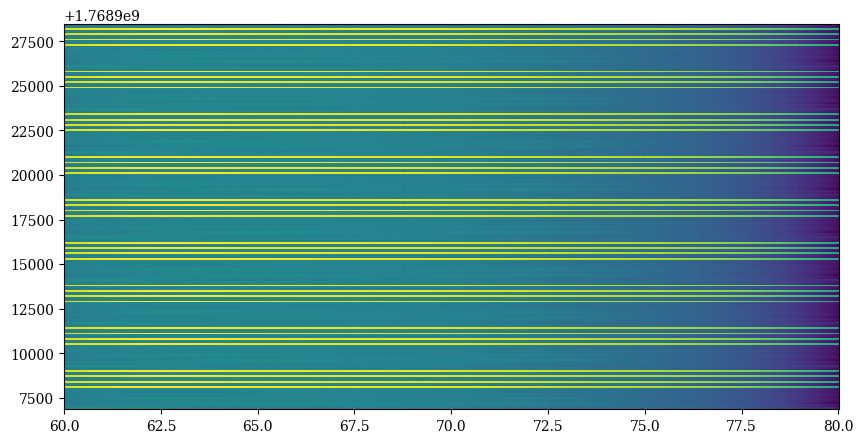

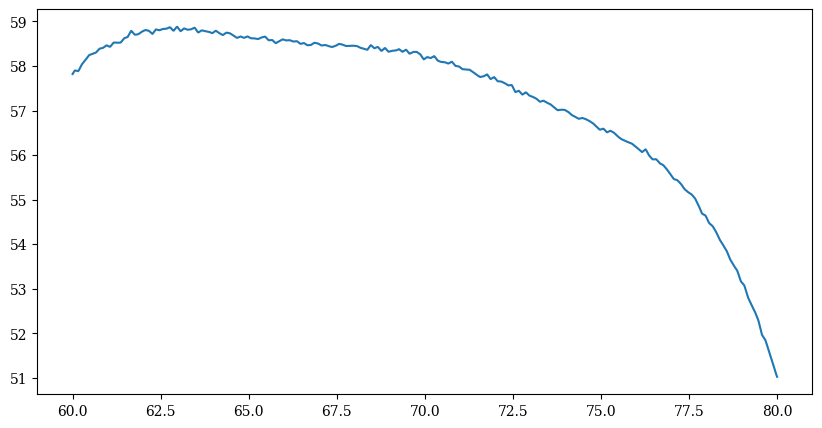

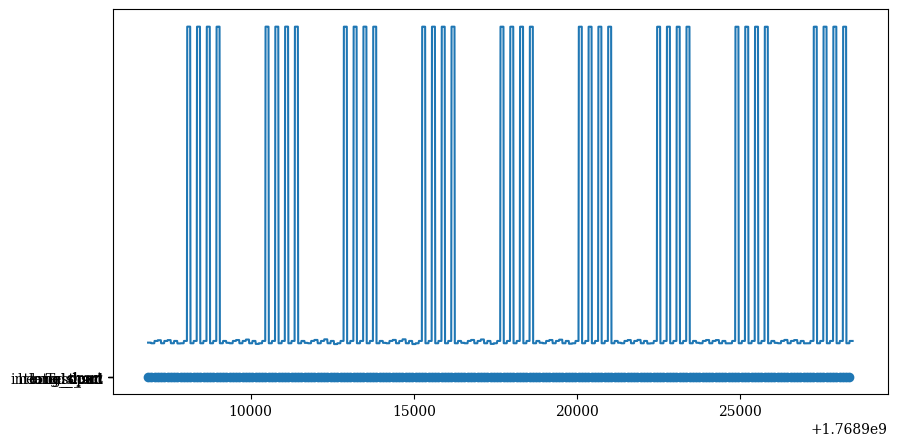

<class 'str'>
<class 'numpy.float64'>
internal_load
[272.91200139 273.03004448 272.95159718 ... 272.98091214 272.90018091
 273.16152217]
----
heated_load
[313.00570365 312.92869889 312.72702713 ... 313.01898752 313.11836419
 313.2326021 ]
----
long_open
[272.93884656 272.97443253 272.89936834 ... 273.10090615 272.87773897
 272.88516313]
----
long_short
[272.95613306 273.05035978 272.96812376 ... 272.93492643 272.91342714
 273.17728208]
----
open
[272.92169163 272.9178307  273.10906819 ... 273.0083579  273.13201027
 272.93386614]
----
short
[272.98432578 273.05971322 273.02875681 ... 273.10730057 272.944868
 272.96021413]
----
Test_src
[6000.0060719  5999.98742308 5999.96411746 ... 5999.93407662 5999.94884578
 5999.89470668]
----


In [247]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.scatter(observation_handler_obj.switch_times, observation_handler_obj.switch_states)
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


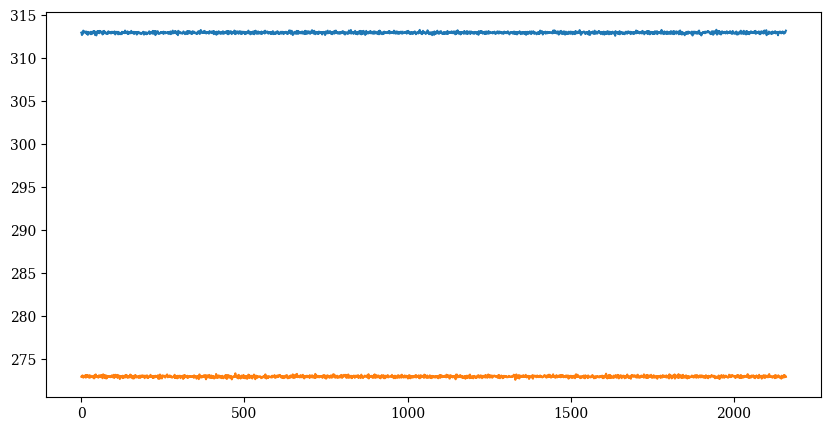

In [248]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [249]:
print(observation_handler_obj.data.shape)
print(observation_handler_obj.data)

(2160, 1024)
[[298428.32850524 301492.80663355 303419.20357802 ...  62117.87480343
   61831.18692619  61192.81698894]
 [298735.32773441 301745.74441654 303887.04089993 ...  62251.5048145
   61717.86712204  61432.37247689]
 [300126.57026304 302324.54846854 301902.08658704 ...  62085.25716381
   61758.52677654  61646.51981701]
 ...
 [258917.26081412 260630.69665466 261428.95952118 ...  50267.96243595
   49538.08033246  49117.84582302]
 [258619.68315596 259768.72764941 261510.39534991 ...  50105.19733327
   49315.42696771  48917.89659413]
 [259626.52623873 260564.45282086 261688.80055434 ...  49888.51945894
   49568.19784099  48881.6435113 ]]


In [250]:
print(observation_handler_obj.temperature_dict)

{'internal_load': array([272.91200139, 273.03004448, 272.95159718, ..., 272.98091214,
       272.90018091, 273.16152217], shape=(2160,)), 'heated_load': array([313.00570365, 312.92869889, 312.72702713, ..., 313.01898752,
       313.11836419, 313.2326021 ], shape=(2160,)), 'long_open': array([272.93884656, 272.97443253, 272.89936834, ..., 273.10090615,
       272.87773897, 272.88516313], shape=(2160,)), 'long_short': array([272.95613306, 273.05035978, 272.96812376, ..., 272.93492643,
       272.91342714, 273.17728208], shape=(2160,)), 'open': array([272.92169163, 272.9178307 , 273.10906819, ..., 273.0083579 ,
       273.13201027, 272.93386614], shape=(2160,)), 'short': array([272.98432578, 273.05971322, 273.02875681, ..., 273.10730057,
       272.944868  , 272.96021413], shape=(2160,)), 'Test_src': array([6000.0060719 , 5999.98742308, 5999.96411746, ..., 5999.93407662,
       5999.94884578, 5999.89470668], shape=(2160,))}


In [251]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


In [252]:
print(final_states)

[np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short')]


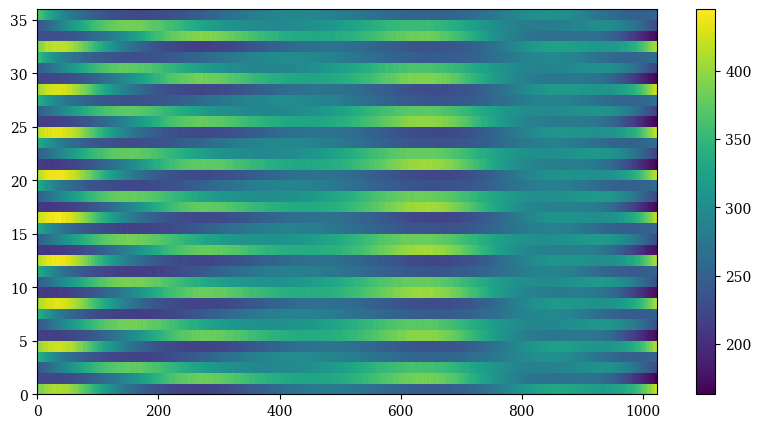

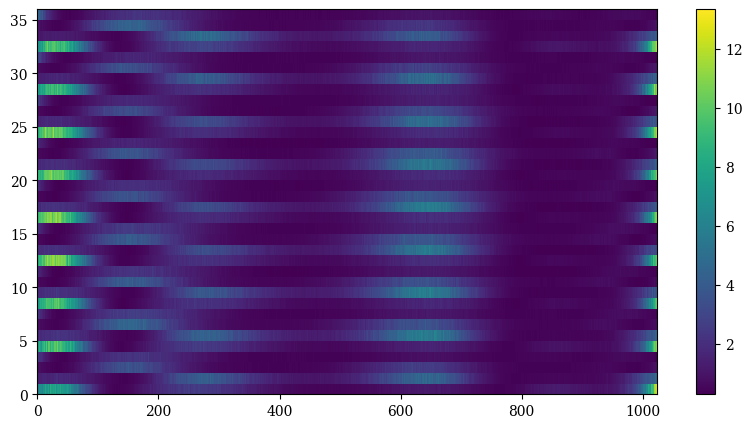

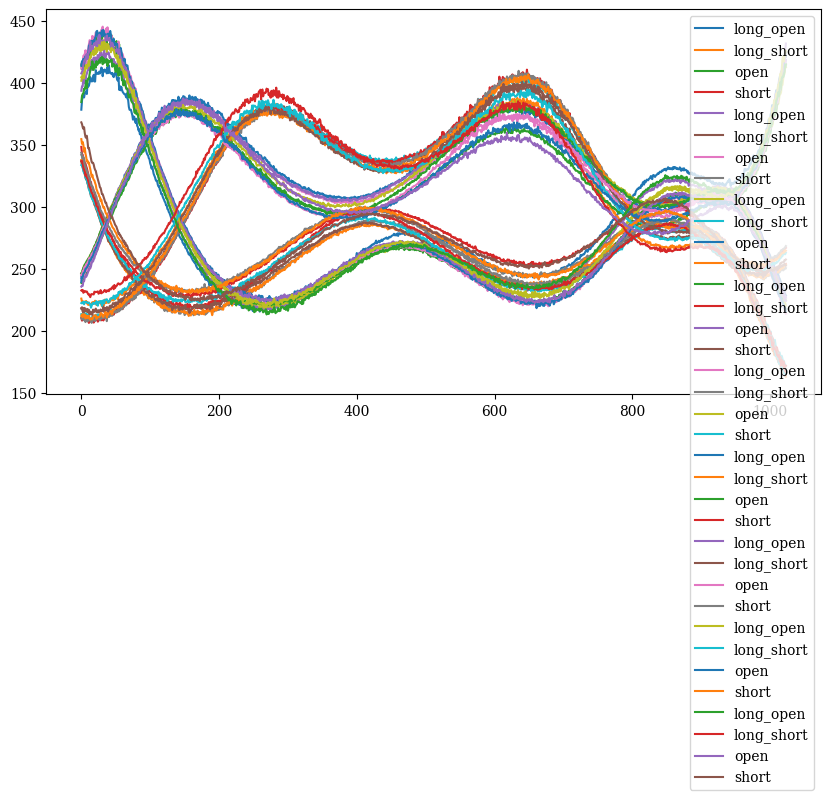

In [253]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [254]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

<class 'float'>
8640000.0


In [255]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

print(np.array(observation_handler_obj.freqs[0]))
print(type(np.array(observation_handler_obj.freqs[0])))

print(final_times[0])
print(type(np.array(final_times[0])))

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)


60.0
<class 'numpy.ndarray'>
1768907003.643347
<class 'numpy.ndarray'>
<function array_normalisation.<locals>.array_norm_func at 0x1182ba5c0>


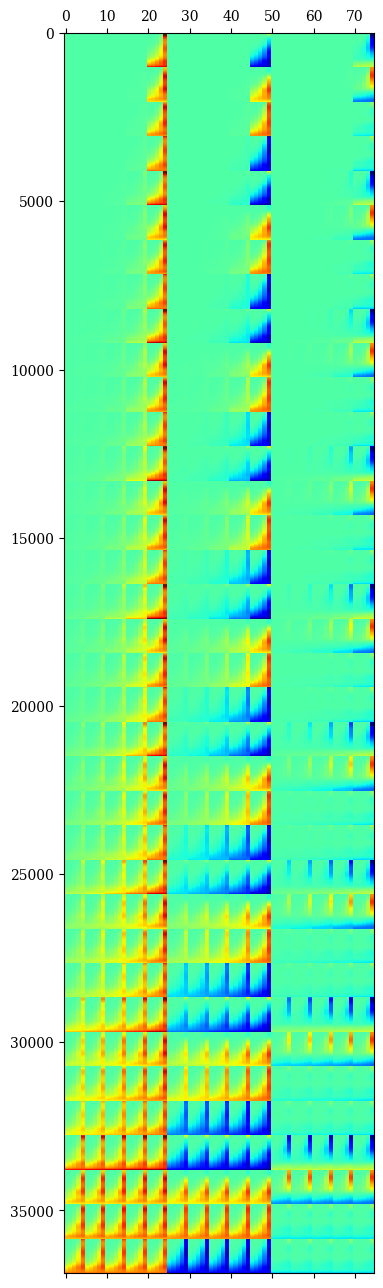

In [256]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

(36864,)
(36864, 75)
[-2.44999825e+02  4.66695047e+02 -3.00849296e+02  8.10438943e+01
 -8.94306696e+00  6.46284574e+02 -1.23201939e+03  7.80425005e+02
 -1.96452709e+02  1.88756415e+01 -5.75139261e+02  1.10033989e+03
 -6.90606100e+02  1.64316979e+02 -1.31644472e+01 -2.80912789e+01
  1.10860444e+02 -8.07507520e+01 -1.25730912e+01  1.06524714e+01
  4.35009800e+02 -1.13963076e+03  9.44857323e+02 -2.49456063e+02
  3.10021076e+02  4.69028581e+02 -9.60781814e+02  6.22566103e+02
 -1.20979625e+02 -6.14477408e-01 -9.32703381e+02  6.26428869e+03
 -7.96721988e+03  2.88705898e+03 -6.49322392e+01  5.78711328e+02
 -6.20177555e+03  8.75260629e+03 -3.43299809e+03  2.85474070e+01
 -1.12728615e+02  1.07091815e+03 -1.71122070e+03  8.09104806e+02
  2.56006367e+01  3.25884735e+00  9.72302762e+00  1.34126443e+01
 -3.57158583e+01  2.22176847e+01 -1.84470620e+02  5.53216119e+02
 -4.86242838e+02  1.42980366e+02 -9.14024242e+00  4.92306675e+02
 -1.36381583e+03  1.14516278e+03 -3.25902657e+02  1.92780049e+01
 -4.

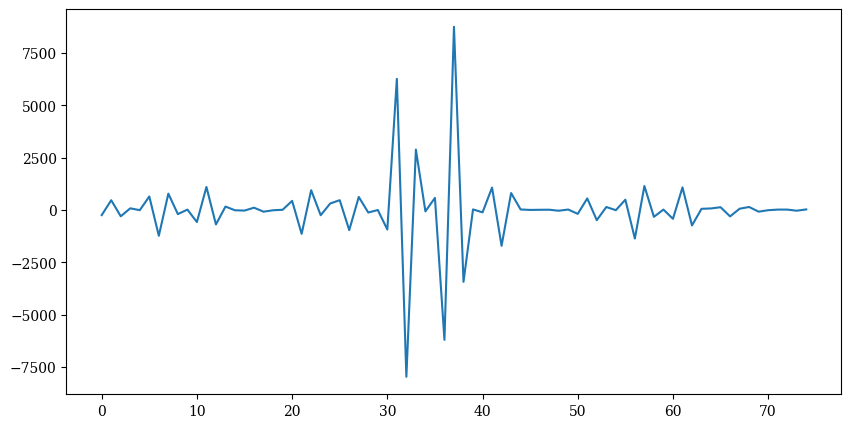

In [257]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [258]:
from gcr.basis_construction import reconstruct_surface

In [259]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

[ -244.99982545   466.69504695  -300.84929629    81.04389427
    -8.94306696   646.28457403 -1232.01939012   780.42500486
  -196.45270913    18.87564152  -575.13926065  1100.33988562
  -690.60610024   164.31697904   -13.16444724   -28.09127888
   110.86044418   -80.75075202   -12.57309119    10.65247139
   435.00979964 -1139.63075708   944.85732338  -249.45606263
   310.0210759 ]
[ 4.69028581e+02 -9.60781814e+02  6.22566103e+02 -1.20979625e+02
 -6.14477408e-01 -9.32703381e+02  6.26428869e+03 -7.96721988e+03
  2.88705898e+03 -6.49322392e+01  5.78711328e+02 -6.20177555e+03
  8.75260629e+03 -3.43299809e+03  2.85474070e+01 -1.12728615e+02
  1.07091815e+03 -1.71122070e+03  8.09104806e+02  2.56006367e+01
  3.25884735e+00  9.72302762e+00  1.34126443e+01 -3.57158583e+01
  2.22176847e+01]
[ -184.47062033   553.21611897  -486.24283788   142.98036565
    -9.14024242   492.30667549 -1363.81583062  1145.16277528
  -325.90265742    19.27800491  -421.01304541  1079.79909392
  -738.39916691    56.5592

In [260]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


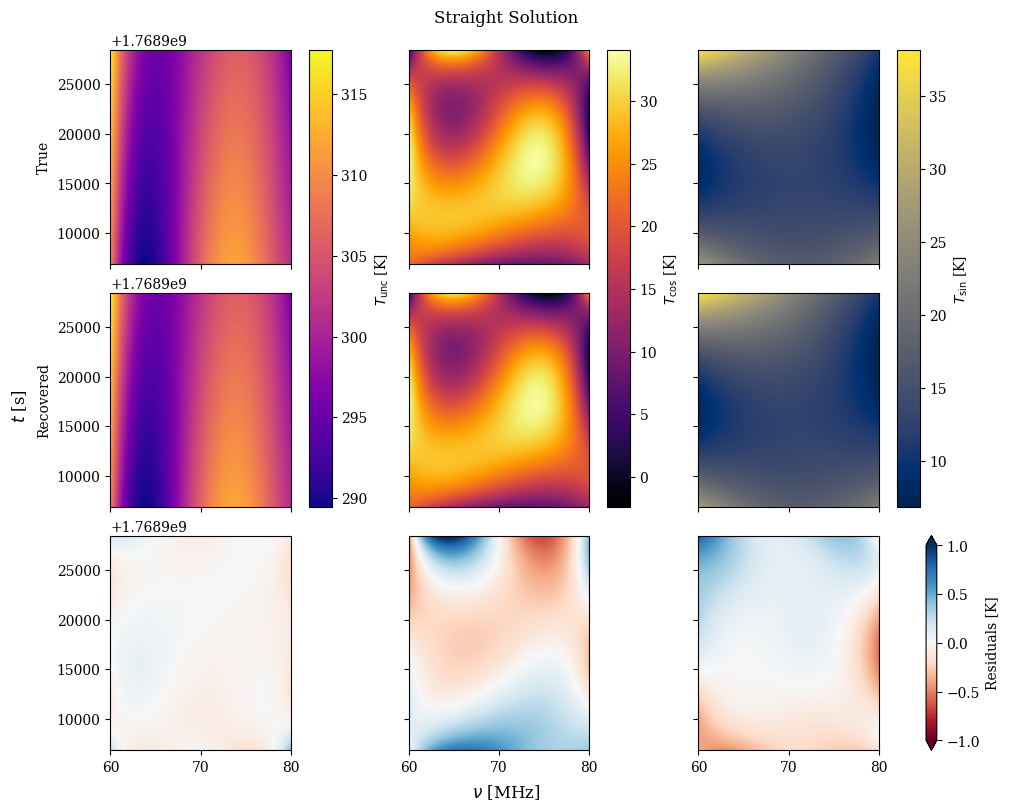

In [261]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [262]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 2
S_inv = np.zeros_like(t_vec)# 1/S_cov
S_inv = 1/S_cov #  np.zeros_like(t_vec)# 1/S_cov

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.random.normal(loc=0, scale=1, size=flattened_data.shape),
                        omega_t=np.random.normal(loc=0, scale=1, size=t_vec.shape))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]


In [263]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


[ -244.99474331   466.70370854  -300.84566477    81.04074662
    -8.98471351   646.29336315 -1232.0125559    780.4330602
  -196.45576608    18.84511616  -575.13360536  1100.34974814
  -690.60002655   164.31966518   -13.18294515   -28.09157291
   110.86386668   -80.75090445   -12.57581083    10.65668553
   435.0019859  -1139.64286973   944.84645821  -249.46896612
   310.03860039]
[ 4.69022169e+02 -9.60790216e+02  6.22562687e+02 -1.20980321e+02
 -6.00244436e-01 -9.32711937e+02  6.26428353e+03 -7.96722625e+03
  2.88706005e+03 -6.49240873e+01  5.78707694e+02 -6.20178204e+03
  8.75260354e+03 -3.43300024e+03  2.85525449e+01 -1.12729195e+02
  1.07091947e+03 -1.71122285e+03  8.09106482e+02  2.55982242e+01
  3.28709604e+00  9.74638245e+00  1.34276880e+01 -3.57206325e+01
  2.21811933e+01]
[ -184.4834272    553.20547387  -486.2576505    142.9673138
    -9.13439107   492.29583106 -1363.83034258  1145.14946881
  -325.92044043    19.28885555  -421.02864676  1079.78536148
  -738.4177764     56.541379

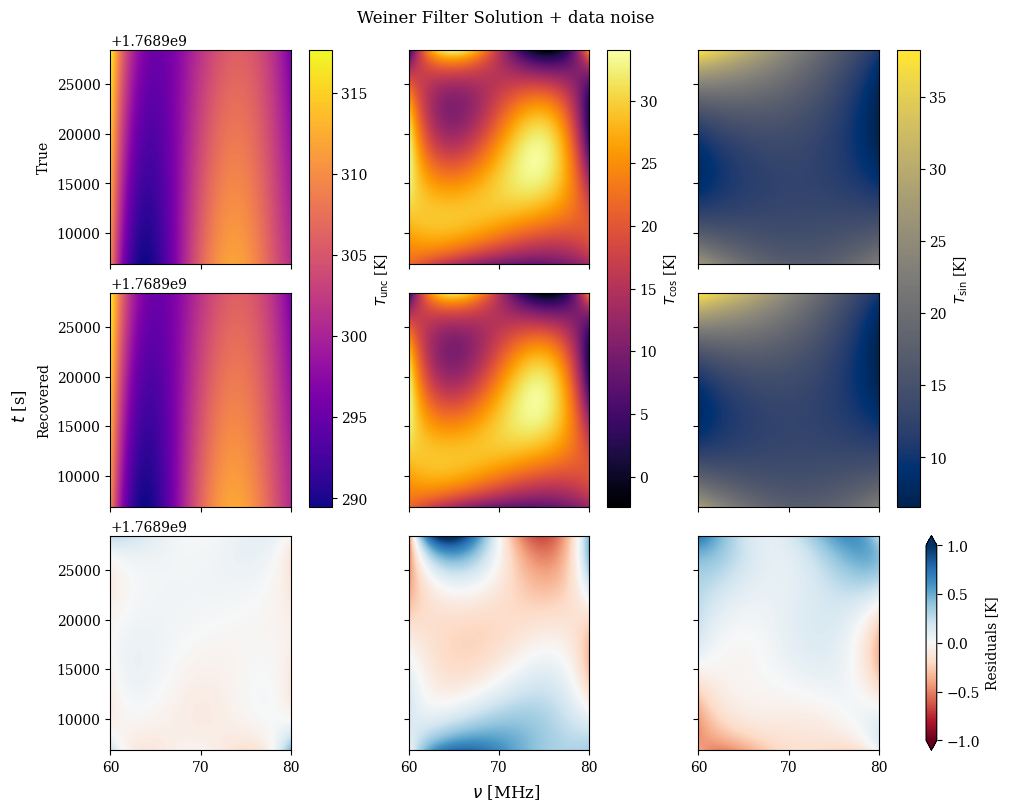

In [264]:

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution + data noise')
plt.show()


In [265]:
t_vec - gcr_wsol

array([-0.00508213, -0.00866158, -0.00363152,  0.00314764,  0.04164656,
       -0.00878912, -0.00683422, -0.00805534,  0.00305695,  0.03052537,
       -0.00565529, -0.00986252, -0.00607369, -0.00268615,  0.01849791,
        0.00029403, -0.0034225 ,  0.00015243,  0.00271964, -0.00421414,
        0.00781374,  0.01211265,  0.01086516,  0.01290349, -0.0175245 ,
        0.00641144,  0.008402  ,  0.0034157 ,  0.00069554, -0.01423297,
        0.00855528,  0.00516363,  0.00637166, -0.00106974, -0.00815191,
        0.00363412,  0.00649117,  0.00274351,  0.0021564 , -0.0051379 ,
        0.00057997, -0.00132025,  0.00215641, -0.00167687,  0.00241246,
       -0.02824869, -0.02335483, -0.01504373,  0.0047742 ,  0.03649148,
        0.01280687,  0.0106451 ,  0.01481262,  0.01305185, -0.00585135,
        0.01084442,  0.01451196,  0.01330648,  0.01778301, -0.01085064,
        0.01560135,  0.01373244,  0.01860949,  0.01785303, -0.01559678,
        0.01697447,  0.0208936 ,  0.02047233,  0.02224469, -0.02